# Test 2b - Merge, Aggregate, Visualize

## Introduction

This problem tests your ability to merge, aggregate, and visualize data.
You'll work with realistic business data to answer questions about product profitability.

Before submitting, ensure your notebook:

- Includes your verification info (Banner ID and code) as the first cell
- Runs completely with "Kernel → Restart & Run All"
- Shows your work (don't just print final answers)
- Includes your interpretation responses at the end

## Dataset: Bean & Brew Coffee Shop

You've been hired to analyze sales data for Bean & Brew, a local coffee shop chain with three locations. The owner wants to understand which products are most profitable and how profitability varies across locations.

There are two data files:

- `sales.csv` - Individual transaction records
  - `transaction_id`: Unique transaction identifier
  - `timestamp`: Date and time of purchase (format: 'YYYY-MM-DD HH:MM:SS')
  - `location`: Store location ('Downtown', 'Campus', 'Suburb')
  - `product_id`: Product identifier (links to products table)
  - `quantity`: Number of units sold
  - `revenue`: Total revenue from transaction
  - `payment_method`: Payment type ('Cash', 'Credit', 'Mobile')
  - `loyalty_member`: Boolean indicating if customer is loyalty program member
- `products.csv` - Product catalog
  - `product_id`: Unique product identifier
  - `name`: Product name
  - `category`: Product category ('Coffee', 'Tea', 'Pastry', 'Sandwich')
  - `cost`: Cost to make/acquire one unit (for profit calculation)

The dataset contains two weeks of sales data (approximately 3,000 transactions) across 18 products. It includes both regular and premium items in each category.

We are interested in learning which product categories generate the most profit, and how does profitability vary across locations? Complete the following tasks to answer those questions and more.

## Scoring

Total: 30 points (+ 5 bonus)

- Tasks 1-6: 18 points
- Interpretation (Questions 1-4): 12 points
- Bonus: 5 points (optional)

## Generate Your Dataset

Before starting the analysis, you need to generate your unique dataset using your Banner ID.

1. Open a terminal in the folder containing `generate_test2b_data.py`
2. Activate your conda virtual environment
3. Run: `python generate_test2b_data.py`
4. Enter your 9-digit Banner ID when prompted (you'll enter it twice to confirm)

The script will create two files in the `data/` folder:

- `data/products.csv` - Product catalog
- `data/sales.csv` - Transaction records

Important: At the end, the script displays a verification block like this:

```
======================================================================
DATA VERIFICATION INFORMATION
======================================================================
banner id:          904123456
verification code:  5e0dXXXXXXXX
======================================================================
```

Copy the banner id and verification code lines and paste them into the cell below. This is required for submission.


DATA VERIFICATION INFORMATION

1. banner id:          904062644
2. verification code:  20510110de76


## Setup: Load the Data

Run the cell below to load the data. The code is provided for you.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (provided)
sales = pd.read_csv('data/sales.csv', parse_dates=['timestamp'])
products = pd.read_csv('data/products.csv')

print(f"Sales: {len(sales)} transactions")
print(f"Products: {len(products)} items in catalog")
print()
print("Sales preview:")
sales.head()

Sales: 2700 transactions
Products: 18 items in catalog

Sales preview:


,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member
0,1002,2025-11-14 06:29:00,Campus,108,1.0,2.62,Mobile,False
1,1003,2025-11-14 06:44:00,Suburb,107,1.0,1.92,Credit,False
2,1005,2025-11-14 06:47:00,Downtown,107,1.0,2.22,Mobile,False
3,1004,2025-11-14 06:52:00,Campus,105,1.0,3.45,Credit,False
4,1001,2025-11-14 06:57:00,Downtown,106,1.0,10.74,Credit,True


In [2]:
# Products catalog
products

,product_id,name,category,cost
0,101,Espresso,Coffee,1.2
1,102,Cappuccino,Coffee,1.8
2,103,Latte,Coffee,1.9
3,104,Americano,Coffee,1.0
4,105,Cold Brew,Coffee,1.5
5,106,Nitro Cold Brew,Coffee,2.5
6,107,Green Tea,Tea,0.8
7,108,Chai Latte,Tea,1.2
8,109,Herbal Tea,Tea,0.7
9,110,Premium Matcha,Tea,2.2


## Task 1: Data Quality Check

Investigate the sales data quality and coverage. Your code should answer the following questions:

1. How many missing values are in each column?
2. How many unique product IDs appear in the sales data? Compare this to the catalog size.
3. What is the date range (earliest and latest transaction)?

### Your Code

In [3]:
# Task 1: use isna(), nunique(), min/max on timestamp

#find and print the missing values for each data set 
print(f'Sales missing values:\n{sales.isna().sum()}') #sales
print(f'\nProduct missing values:\n{products.isna().sum()}') #products

#print the number of unique IDs for products and sales
print(f'\nUnique product IDs:{len(pd.unique(sales["product_id"]))}') #sales
print(f'Product IDs in Catalog:{len(pd.unique(products["product_id"]))}\n') #products

# this was done before later tasks, left it in for completeness sake
# this finds the unmatched IDs and prints them
sales_ids = pd.unique(sales["product_id"]) #save the unique IDs for sales
product_ids = pd.unique(products["product_id"]) #save the unique IDs for products
unmatched_ids = [] #initialize empty list
for x in sales_ids: #loop through each of sales IDs
    if x not in product_ids: #check if the ID is in products
        unmatched_ids.append(x) #add to empty list if so
print(f'Unmatched IDs:\n{unmatched_ids}\n') #print results

#find and print the earliest and latest dates
print(f'Earliest Date: {sales["timestamp"].min()}') #earliest
print(f'Latest Date: {sales["timestamp"].max()}') #latest

Sales missing values:
transaction_id    0
timestamp         0
location          0
product_id        0
quantity          3
revenue           5
payment_method    0
loyalty_member    0
dtype: int64

Product missing values:
product_id    0
name          0
category      0
cost          0
dtype: int64

Unique product IDs:21
Product IDs in Catalog:18

Unmatched IDs:
[np.int64(199), np.int64(201), np.int64(200)]

Earliest Date: 2025-11-14 06:29:00
Latest Date: 2025-11-27 21:32:00


## Task 2: Merge Sales with Products

Merge the sales and products DataFrames to add product information (name, category, cost) to each transaction.

### Your Code

In [4]:
# Task 2: use pd.merge() with appropriate join type

#this merges sales and products using product_id on sales
salesProducts = pd.merge(sales, products, on = "product_id", how = 'left')
#shows the merge
salesProducts

,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member,name,category,cost
0,1002,2025-11-14 06:29:00,Campus,108,1.0,2.62,Mobile,False,Chai Latte,Tea,1.2
1,1003,2025-11-14 06:44:00,Suburb,107,1.0,1.92,Credit,False,Green Tea,Tea,0.8
2,1005,2025-11-14 06:47:00,Downtown,107,1.0,2.22,Mobile,False,Green Tea,Tea,0.8
3,1004,2025-11-14 06:52:00,Campus,105,1.0,3.45,Credit,False,Cold Brew,Coffee,1.5
4,1001,2025-11-14 06:57:00,Downtown,106,1.0,10.74,Credit,True,Nitro Cold Brew,Coffee,2.5
...,...,...,...,...,...,...,...,...,...,...,...
2695,3691,2025-11-27 20:35:00,Campus,114,1.0,4.74,Credit,False,Cinnamon Roll,Pastry,1.4
2696,3689,2025-11-27 20:47:00,Suburb,108,1.0,3.01,Mobile,True,Chai Latte,Tea,1.2
2697,3692,2025-11-27 20:56:00,Downtown,101,1.0,3.22,Mobile,True,Espresso,Coffee,1.2
2698,3693,2025-11-27 21:04:00,Downtown,101,1.0,3.51,Mobile,False,Espresso,Coffee,1.2


## Task 3: Verify the Merge

After merging, verify that the merge worked correctly:

1. Compare the shape of the merged DataFrame to the original sales data
2. Check if any rows have missing values in the product columns (name, category, cost)
3. If there are missing values, identify which product_id(s) are causing the problem

### Your Code

In [5]:
# Task 3: check shape, isna() on product columns, filter to find problem IDs

#check the shape of the merged dataframe
print(f'Shape of the new data frame: {salesProducts.shape}')

#check if there are missing values in the added columns
print(f"\nNumbder of missing values of product columns:\n{salesProducts[['name', 'category', 'cost']].isna().sum()}\n")

#a much cleaner way to get the missing IDs
unmatched_ids = salesProducts[salesProducts['name'].isna()]
#print the problematic IDs
print(f"The unmatched IDs are: {unmatched_ids['product_id'].unique()}")


Shape of the new data frame: (2700, 11)

Numbder of missing values of product columns:
name        8
category    8
cost        8
dtype: int64

The unmatched IDs are: [199 201 200]


## Task 4: Profit by Category

First, calculate profit for each transaction: `profit = revenue - (cost × quantity)`

Then summarize profitability by product category. Your code should return a table that shows both total profit and number of transactions for each category. Sort it by total profit (highest first).

### Your Code

In [6]:
# Task 4: create profit column, then groupby with .agg()

#add the profit column to salesProducts
salesProducts['profit'] = salesProducts['revenue'] - ( salesProducts['cost'] * salesProducts['quantity'] )
#check the new column
print(salesProducts.head(5))

#create a data frame that shows each category's profit and transacton count
cateFrame = salesProducts.groupby('category')[['profit','transaction_id']].agg({
    'profit' : "sum", #get total profit
    'transaction_id' : 'count'}).rename(columns={ #get transaction count and start rename
    'profit' : 'total_profit', #rename profit to total profit
    'transaction_id': 'transactions_count'}) #rename transaction id to transaction count
#sort the frame by order
cateFrame = cateFrame.sort_values(by='total_profit', ascending = False)
#show results
print(cateFrame)

   transaction_id           timestamp  location  product_id  quantity  \
0            1002 2025-11-14 06:29:00    Campus         108       1.0   
1            1003 2025-11-14 06:44:00    Suburb         107       1.0   
2            1005 2025-11-14 06:47:00  Downtown         107       1.0   
3            1004 2025-11-14 06:52:00    Campus         105       1.0   
4            1001 2025-11-14 06:57:00  Downtown         106       1.0   

   revenue payment_method  loyalty_member             name category  cost  \
0     2.62         Mobile           False       Chai Latte      Tea   1.2   
1     1.92         Credit           False        Green Tea      Tea   0.8   
2     2.22         Mobile           False        Green Tea      Tea   0.8   
3     3.45         Credit           False        Cold Brew   Coffee   1.5   
4    10.74         Credit            True  Nitro Cold Brew   Coffee   2.5   

   profit  
0    1.42  
1    1.12  
2    1.42  
3    1.95  
4    8.24  
          total_profit  tr

## Task 5: Profit by Category and Location

Analyze how profitability varies by both category and location. Your code should produce a table that shows the following for every combination of category and location:

- Total profit
- Average profit per transaction
- Number of transactions

Display the results as a flat table (i.e., without a nested/hierarchical index).

### Your Code

In [7]:
# Task 5: groupby multiple columns, .agg() with dict, reset_index()
summary = salesProducts.groupby(['category', 'location']).agg({
    'profit' : ["sum", 'mean'], #get profit sum and mean
    'transaction_id' : 'count'}).rename(columns={'transaction_id': 'Transactions_count'}) #get transaction count and rename to transaction count
#reset index 
summary.reset_index()

category  location   profit           Transactions_count
                            sum      mean              count
0     Coffee    Campus   974.65  1.980996                493
1     Coffee  Downtown  1053.55  3.107817                340
2     Coffee    Suburb   171.28  2.412394                 71
3     Pastry    Campus   625.19  2.551796                245
4     Pastry  Downtown   694.86  3.676508                189
5     Pastry    Suburb   397.08  2.836286                140
6   Sandwich    Campus   806.48  5.376533                150
7   Sandwich  Downtown  2743.42  8.441292                329
8   Sandwich    Suburb   927.57  6.353219                148
9        Tea    Campus   173.28  1.089811                159
10       Tea  Downtown   339.87  1.942114                175
11       Tea    Suburb   362.54  1.432964                253

## Task 6: Visualize Category Profitability

Create a bar chart showing total profit by product category. Use seaborn and ensure that the result:

- Has clearly labeled categories
- Includes a descriptive title
- Makes it clear which category is most/least profitable

### Your Code

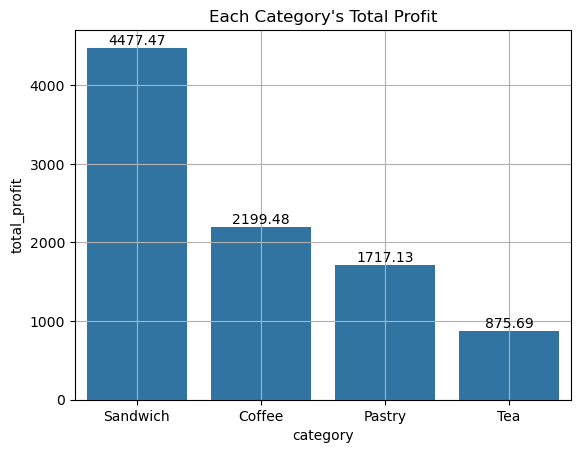

In [8]:
# Task 6: use sns.barplot() with aggregated data

#makes a bar chart for the cateFrame data
profitBar = sns.barplot(data=cateFrame, x='category', y='total_profit') #makes the plot and sets the x and y axis
profitBar.bar_label(profitBar.containers[0], fontsize=10) #add the numbers at the top of each bar
profitBar.set(title="Each Category's Total Profit") #adds the title
profitBar.grid() #adds the grid to make it easier to read

## Interpretation

Concisely answer the following questions based on your analysis.


1. What might go wrong if you did not verify the merge in Task 3 before proceeding with the analysis?
2. In Tasks 4 and 5, you aggregated data at different levels of detail (by category, then by category and location). How did this change what you could learn from the data?
3. Reflect on the patterns you discovered in your analysis. What valuable insights did your work generate?
4. The coffee shop owner asks: "Based on your analysis, what's the single most important thing I should do to improve profitability?" Provide a specific, actionable recommendation. Justify your recommendation with evidence from your analysis (include specific numbers from your results). Also, suggest additional analysis that you feel might be worthwhile.

### Your Answers

1. Without verifying the the merge, the table could have been merged wrong so the dimensions could have changed. Like if an inner merge was used, several transaction rows would be lost. Verifying also showed where the NaN values where created from the merge, allowing them to be taken care of then if desired. 
2. Going from just category to category and location increased the level of detail for each category. With more details, it shows how location impacts on each category's total profit, average profit, and transaction count. Knowing this level of detail can allow for better analysis and conclusions. Such as knowing that coffee at the suburb location has the lowest transaction count can lead to reducing coffee supplies at the location, increasing avaliable space. The level of detailed changes what we can learn from the data to how different categorical datas interact with each other and the results.
3. The insight generated shows how category and location impact total profit, average profit, and transaction count. Such as sandwiches are the most profitable by a wide margin with sandwiches at the downtown location being the biggest contribuator. Coffee at the campus location has the highest transcation count, while coffee at the suburb location has the lowest transaction count. 
4. What I think is the single most important change to increase profitability is to increase the average profit per coffee sell. It has the highest transaction count but not the highest total profit or average. Specically looking at coffee sells at the campus location would be beneficial since it has the highest transaction counts at 493, but compared to coffee sells at other locations, the average profit is lower. Bringing the average profit of campus coffee close to the average of the downtown location can increase total profit for coffee by over 500. That 500 is calculated by multipling the transaction count of coffee at the campus location with the average profit from the downtown location and minusing the difference. One other recommendation that might be worth looking at is increasing sandwich sells at the downtown location, since it has the highest average profit at 8.44 per transaction.  

## Bonus: Time-Based Analysis (Optional)

For extra credit, investigate a time-based question of your choosing. Examples of questions you could explore include:

- Do sales patterns differ between weekdays and weekends?
- Which hours are busiest at each location?
- Is there a day of the week that stands out for profitability?

For full credit you must:

- State your question clearly
- Show your analysis code
- Summarize what you found in 2-3 sentences

day_of_week
Friday       556
Wednesday    427
Monday       427
Thursday     427
Tuesday      426
Sunday       219
Saturday     218
Name: count, dtype: int64
                      Count
category day_of_week       
Coffee   Friday         205
         Monday         157
         Tuesday        151
         Wednesday      148
         Thursday       137
         Saturday        55
         Sunday          51
Pastry   Friday         112
         Monday          97
         Tuesday         95
         Wednesday       94
         Thursday        92
         Saturday        42
         Sunday          42
Sandwich Friday         120
         Tuesday        102
         Monday          99
         Wednesday       94
         Thursday        91
         Sunday          61
         Saturday        60
Tea      Friday         117
         Thursday       104
         Wednesday       91
         Tuesday         76
         Monday          74
         Sunday          64
         Saturday        61


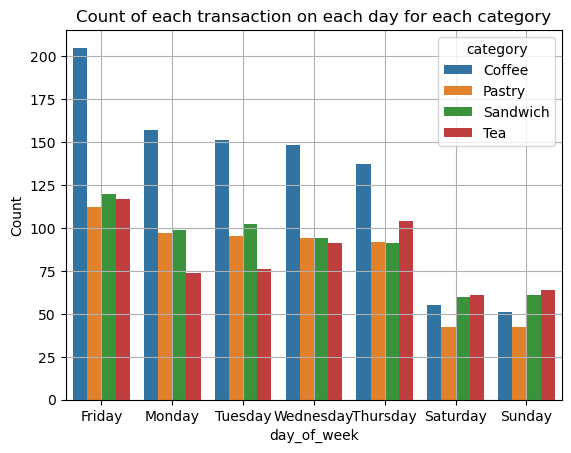

In [9]:
# Bonus: Your time-based analysis here

#How does each catergory vary by day in number of transactions?

# add a column with the day of the week for salesProducts
salesProducts["day_of_week"] = salesProducts['timestamp'].dt.day_name()
#print the counts of each day
print(salesProducts["day_of_week"].value_counts())

#create a group of table of 
timeCate = salesProducts.groupby("category").agg({'day_of_week' : 'value_counts'}).rename(columns={"day_of_week":  'Count'})
#show table
print(timeCate)

# make bar chart of the data
cateBar = sns.barplot(data=timeCate, x= "day_of_week", y = "Count", hue = "category")
cateBar.set(title="Count of each transaction on each day for each category") #adds the title
#cateBar.grid() #adds the grid to make it easier to read
cateBar.grid()


### Your Findings

### Question
* How does each catergory vary by day in number of transactions?
### Findings
* Coffee is the best performer on every week day while Tea performs better on the weekends.
* The weekends perform worse than weekdays.
* Pastries, Sandwiches, and teas sales are usually close to each other when compared to coffee.
* Based on earliest date and and latest date, there are two instances of everyday occuring except for Tuesday, Wednesday, and Thursday, which got an extra occurance.
* Friday is the best performing day while Sunday is the worse performing day.
* Saturday and Sunday could be under preforming because they are only collected from two samples

## Submission

Ensure your notebook:

- Has the verification block (Banner ID and code) as the first cell
- Runs completely from top to bottom without errors
- Shows all task outputs clearly
- Includes all interpretation responses
- Is saved and committed to your repository

Follow the submission instructions on Canvas to submit your work.